### Часть 1. Парсинг.

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [38]:
from bs4 import BeautifulSoup
from fake_useragent import UserAgent
import requests, re

In [40]:
main_page_link = ['https://stopgame.ru/games/best', 'https://stopgame.ru']

In [43]:
# request meme page with chrome user agent
response = requests.get(main_page_link[0], headers={'User-Agent': UserAgent().safari})
response.text

'<!DOCTYPE html>\n<html lang="ru-RU">\n<head>\n  <meta charset="UTF-8">\n  <meta http-equiv="X-UA-Compatible" content="IE=edge">\n  <meta name="viewport" content="width=device-width, initial-scale=1, user-scalable=1, maximum-scale=1">\n    <title>Самые популярные игры | StopGame</title>\n  <!--suppress CssInvalidAtRule, CssUnknownProperty -->\n  <style>\n    @layer old, common, page, component, overrides;\n\n    @view-transition {\n      navigation: auto;\n    }\n  </style>\n  <meta name="description" content="Самые популярные игры - топ игр, с возможностью выбора платформ и сортировки">\n<meta name="keywords" content="самые популярные игры топ лучшие pc xbox ps3 ps4 ps5 iphone ipad бесплатные скачать">\n<meta name="theme-color" content="#161b1d">\n<meta name="msapplication-navbutton-color" content="#161b1d">\n<meta name="apple-mobile-web-app-status-bar-style" content="#161b1d">\n<meta name="csrf-param" content="_stopgame-csrf">\n<meta name="csrf-token" content="qqMFikZN64ZB5EWAQwRLhqZ

In [7]:
html = response.content

In [9]:
soup = BeautifulSoup(html, 'html.parser')

In [15]:
print(soup.prettify()[:2000])

<!DOCTYPE html>
<html lang="ru-RU">
 <head>
  <meta charset="utf-8"/>
  <meta content="IE=edge" http-equiv="X-UA-Compatible"/>
  <meta content="width=device-width, initial-scale=1, user-scalable=1, maximum-scale=1" name="viewport"/>
  <title>
   Самые популярные игры | StopGame
  </title>
  <!--suppress CssInvalidAtRule, CssUnknownProperty -->
  <style>
   @layer old, common, page, component, overrides;

    @view-transition {
      navigation: auto;
    }
  </style>
  <meta content="Самые популярные игры - топ игр, с возможностью выбора платформ и сортировки" name="description"/>
  <meta content="самые популярные игры топ лучшие pc xbox ps3 ps4 ps5 iphone ipad бесплатные скачать" name="keywords"/>
  <meta content="#161b1d" name="theme-color"/>
  <meta content="#161b1d" name="msapplication-navbutton-color"/>
  <meta content="#161b1d" name="apple-mobile-web-app-status-bar-style"/>
  <meta content="_stopgame-csrf" name="csrf-param"/>
  <meta content="df3Ztdt5LeMrYDiRan-4tK3e4eLuiKKJLk8LX

In [45]:
get = soup.find('main', attrs = {'class':'_main_cx34n_316'})
pagination = get.find(string=re.compile(r'из \d+ страниц'))
total_pages = int(re.search(r'из (\d+)', pagination).group(1))
print(total_pages)

622


In [46]:
url_direct_path_game = []

In [ ]:
# Я знаю про корутины, не стал их делать.
for id in range(total_pages):
    pagination_url = f'/topgames?p={id+1}'
    response = requests.get(f"{main_page_link[1]}{pagination_url}", headers={'User-Agent': UserAgent().safari})
    html = response.content
    soup = BeautifulSoup(html, 'html.parser')
    obj = soup.find('main', attrs = {'class':'_main_cx34n_316'})
    obj = obj.find('section', attrs= {'class':'_main-section_82nn8_401'})
    obj = obj.find('div', attrs= {'class':'_games-grid_fl71g_283'})
    obj = obj.find_all('a', href=True)
    for a in obj:
        url_direct_path_game.append(main_page_link[1]+a['href'])


In [54]:
print(len(url_direct_path_game))

18719


In [115]:
title_games = []
description_games = []
score_games = []

In [130]:
from concurrent.futures import ThreadPoolExecutor
import pandas as pd
import time

def parse_game(url):
    try:
        time.sleep(0.5)
        response = requests.get(url, headers={'User-Agent': UserAgent().safari})
        html = response.content
        soup = BeautifulSoup(html, 'html.parser')
        obj_main = soup.find('main', attrs = {'class':'_main_cx34n_316'})
        obj = obj_main.find('section', attrs= {'class':'_right-section_82nn8_479'})
        title_game = obj.find('h1', attrs= {'class':'_game-title_1bso0_702'})
        description_game = obj.find('p', attrs= {'style':'margin: 0'})
        score_game = obj_main.find('span', attrs= {'class':'_game-rating_1bso0_165 _game-rating--green_1bso0_1'})
        # if description_game is None:
        #     description_game = "Нету описания у игры"
        # return title_game, description_game, float(score_game)
        return {
            'title': title_game.text if title_game else None,  
            'description': description_game.text.replace('\n', '').replace('StopGame', '').strip() if description_game else None,
            'score': float(score_game.text) if score_game else 0.0,
        }
    except Exception:
        return {'title': None, 'description': None, 'score': None}

### Часть 2. NLP.

In [165]:
all_data_sets = {}

In [167]:
def segmentation_get_data():
    total_data = int(len(url_direct_path_game)/3000)
    interval = [0, 3000, 6000, 9000, 12000, 15000, 18000]
    for i in range(total_data):
        print("Chpater", i+1)
        with ThreadPoolExecutor(max_workers=5) as pool:
            results = list(pool.map(parse_game, url_direct_path_game[interval[i]:interval[i+1]]))
        # df = pd.DataFrame(results)
        # df = df.dropna(subset=['description'])
        all_data_sets[i+1] = pd.DataFrame(results).dropna(subset=['description'])
        print("Chpater", i+1, "end")
        time.sleep(60)

In [168]:
segmentation_get_data()

Chpater 1
Chpater 1 end
Chpater 2
Chpater 2 end
Chpater 3
Chpater 3 end
Chpater 4
Chpater 4 end
Chpater 5
Chpater 5 end
Chpater 6
Chpater 6 end


In [295]:
df_all = pd.concat([all_data_sets[1], 
                    all_data_sets[2], 
                    all_data_sets[3], 
                    all_data_sets[4], 
                    all_data_sets[5], 
                    all_data_sets[6]], ignore_index=True).dropna(subset=['description'])

In [296]:
df_all

,title,description,score
0,The Witcher 3: Wild Hunt - Blood and Wine,"Добро пожаловать в землю тепла и солнца, в дал...",4.8
1,The Witcher 3: Wild Hunt,"Вы — Геральт из Ривии, наемный убийца чудовищ....",4.7
2,The Witcher 3: Wild Hunt - Hearts of Stone,«Каменные сердца» — это первое крупное дополне...,4.7
3,Silent Hill 2,Джеймс Сандерленд приехал в таинственный город...,4.7
4,Heroes of Might and Magic III: The Shadow of D...,Очередное дополнение к легендарной Heroes of M...,4.7
...,...,...,...
5158,Prison Tycoon 3: Lockdown,Возьмите в свои руки управление частной тюрьмо...,0.0
5159,Fragmented,"Оказавшихся во враждебном чуждом мире, вы долж...",0.0
5160,Zomborg,2000 год. ООН закрыла несколько зон по всему з...,0.0
5161,Dead End Job,Dead End Job — это процедурно генерируемый шут...,0.0


In [172]:
# df_all.to_csv('compare_data.csv')

In [336]:
dfffff = df_all[df_all["score"] == 3.1]

In [339]:
dfffff

,title,description,score
3827,Dracula 4: The Shadow of the Dragon,"Грузовой корабль, перевозящий ценную коллекцию...",3.1
3854,Ground Zero,Эта ретро-игра ужасов переносит вас в постапок...,3.1
3986,Escape from Tarkov,"Escape from Tarkov - хардкорный шутер, где каж...",3.1
3987,RUST,Единственная цель в Rust — выживание. Дикая пр...,3.1
3988,Wheelman,Герой Вина Дизеля Мило Берик прибывает в Барсе...,3.1
...,...,...,...
4202,BRXKEN INSIDE,Спокойной и размеренной жизни Сион приходит ко...,3.1
4203,The Cabin Factory,Ваша работа в корпорации Cabin Factory предель...,3.1
4204,Train Sim World 6,Отправляйтесь в новое путешествие и откройте д...,3.1
4205,Farm Frenzy Collection,Этот сборник из 12 игр станет настоящим подарк...,3.1


In [316]:
df_all = df_all[df_all["score"] > 0]

In [302]:
df_all

,title,description,score
0,The Witcher 3: Wild Hunt - Blood and Wine,"Добро пожаловать в землю тепла и солнца, в дал...",4.8
1,The Witcher 3: Wild Hunt,"Вы — Геральт из Ривии, наемный убийца чудовищ....",4.7
2,The Witcher 3: Wild Hunt - Hearts of Stone,«Каменные сердца» — это первое крупное дополне...,4.7
3,Silent Hill 2,Джеймс Сандерленд приехал в таинственный город...,4.7
4,Heroes of Might and Magic III: The Shadow of D...,Очередное дополнение к легендарной Heroes of M...,4.7
...,...,...,...
4202,BRXKEN INSIDE,Спокойной и размеренной жизни Сион приходит ко...,3.1
4203,The Cabin Factory,Ваша работа в корпорации Cabin Factory предель...,3.1
4204,Train Sim World 6,Отправляйтесь в новое путешествие и откройте д...,3.1
4205,Farm Frenzy Collection,Этот сборник из 12 игр станет настоящим подарк...,3.1


In [299]:
print(df_all["score"].describe()) 

count    4205.000000
mean        3.698597
std         0.353621
min         3.100000
25%         3.400000
50%         3.700000
75%         3.900000
max         4.800000
Name: score, dtype: float64


In [278]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [300]:
X_train, X_test, y_train, y_test = train_test_split(
    df_all["description"], df_all["score"], test_size=0.25, random_state=42
)

In [303]:
nltk.download('stopwords')
stop_words = nltk.corpus.stopwords.words('russian')

[nltk_data] Downloading package stopwords to /Users/bot/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [326]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    stop_words=stop_words,
    min_df=3,
    max_df=0.9,
    norm=None,
)

In [327]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [328]:
print(f"Train shape: {X_train_tfidf.shape}, Test shape: {X_test_tfidf.shape}")

Train shape: (3153, 7051), Test shape: (1052, 7051)


In [329]:
param_grid = {"alpha": [0.01, 0.1, 1.0, 10.0, 100.0]}
grid = GridSearchCV(Ridge(), param_grid, cv=5, scoring="neg_mean_squared_error")
grid.fit(X_train_tfidf, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate paramete

In [330]:
print(f"Best alpha: {grid.best_params_['alpha']}")

Best alpha: 100.0


In [331]:
y_pred = grid.predict(X_test_tfidf)
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred):.4f}")
print(f"R2:   {r2_score(y_test, y_pred):.4f}")

RMSE: 0.3889
MAE:  0.3126
R2:   -0.1511


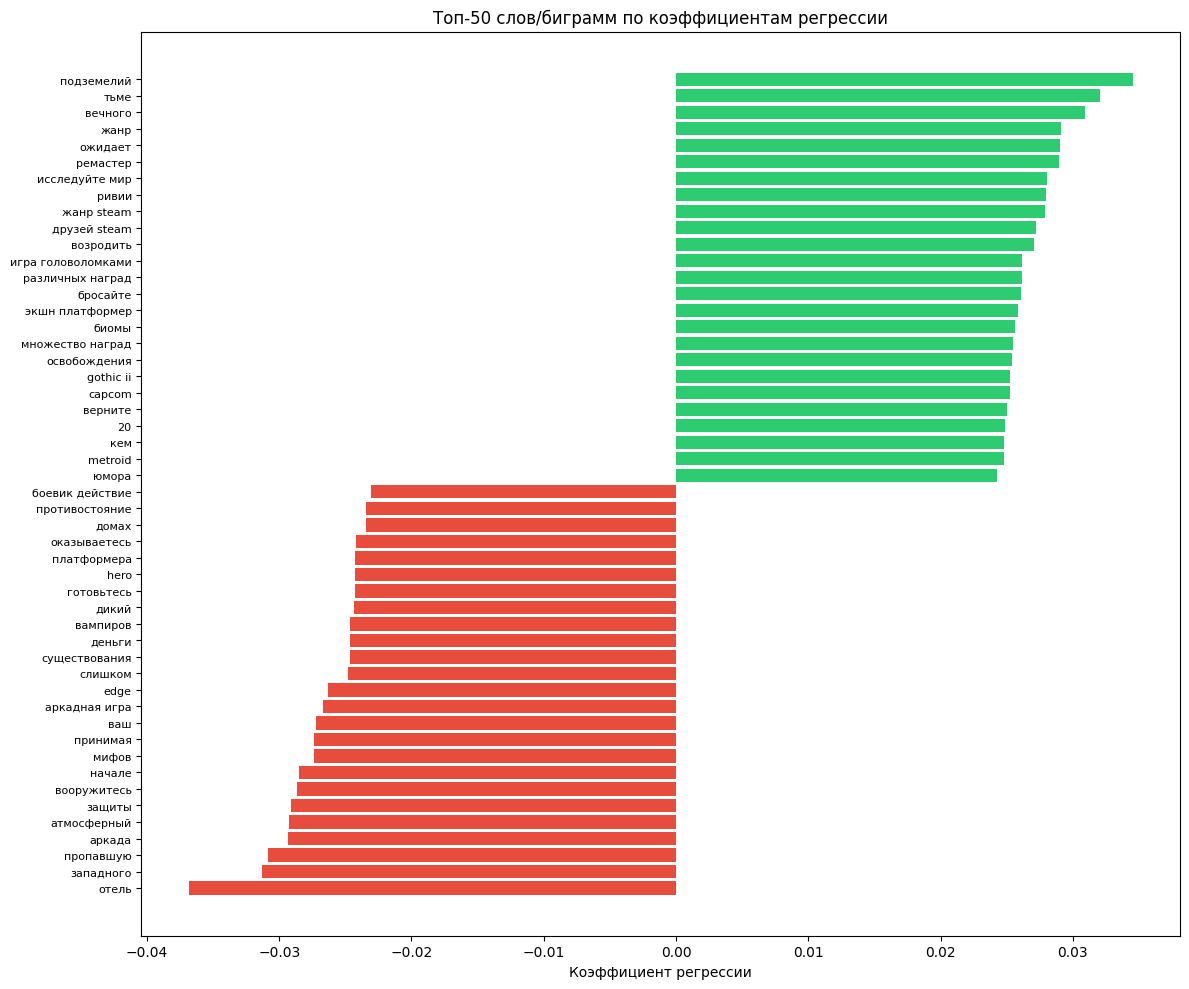


Топ-25 положительных:
  подземелий                     0.0345
  тьме                           0.0320
  вечного                        0.0309
  жанр                           0.0291
  ожидает                        0.0290
  ремастер                       0.0290
  исследуйте мир                 0.0280
  ривии                          0.0279
  жанр steam                     0.0279
  друзей steam                   0.0272
  возродить                      0.0270
  игра головоломками             0.0262
  различных наград               0.0261
  бросайте                       0.0261
  экшн платформер                0.0259
  биомы                          0.0256
  множество наград               0.0255
  освобождения                   0.0254
  gothic ii                      0.0253
  capcom                         0.0253
  верните                        0.0250
  20                             0.0249
  кем                            0.0248
  metroid                        0.0248
  юмора          

In [332]:
model = grid.best_estimator_
coefs = model.coef_
feature_names = np.array(tfidf.get_feature_names_out())

top_pos_idx = np.argsort(coefs)[-25:]
top_neg_idx = np.argsort(coefs)[:25]

top_idx = np.concatenate([top_neg_idx, top_pos_idx])
top_features = feature_names[top_idx]
top_coefs = coefs[top_idx]

plt.figure(figsize=(12, 10))
colors = ["#e74c3c" if c < 0 else "#2ecc71" for c in top_coefs]
plt.barh(range(len(top_coefs)), top_coefs, color=colors)
plt.yticks(range(len(top_coefs)), top_features, fontsize=8)
plt.xlabel("Коэффициент регрессии")
plt.title("Топ-50 слов/биграмм по коэффициентам регрессии")
plt.tight_layout()
plt.savefig("top50_coefs.png", dpi=150)
plt.show()

print("\nТоп-25 положительных:")
for i in top_pos_idx[::-1]:
    print(f"  {feature_names[i]:30s} {coefs[i]:.4f}")
print("\nТоп-25 отрицательных:")
for i in top_neg_idx:
    print(f"  {feature_names[i]:30s} {coefs[i]:.4f}")

Высокие оценки ассоциированы с известными франшизами, RPG-элементами и наградами. <br>
Низкие — с аркадами, простыми жанрами и коммерческими мотивами.

In [341]:
descriptions = [
    "Скучная игра с багами и плохой графикой",
    "Великолепная RPG с глубоким сюжетом",
    "Эпическое приключение с потрясающей графикой и захватывающим сюжетом",
    """События игры происходят на заброшенной лунной базе, где игрокам предстоит взять на себя роль исследователя в тяжелом скафандре. 
    Основная цель — защитить загадочную девочку-андроида по имени Диана и найти способ вернуться на Землю. Мир игры сочетает в себе элементы научной фантастики и 
    сюрреализма: по сюжету привычная реальность была искажена, а лунная станция находится под контролем взбесившегося ИИ и враждебных роботов.""",
    """Легендарная серия возвращается: от студии FromSoftware — новая глава культовой франшизы, поднимающая планку жанра. 
    Плавный бой без просадок FPS, адаптивная сложность, глубокая система прокачки и проработанный открытый мир. 
    Каждое столкновение — это вызов, а каждая победа — заслуженная награда.""",
    """Добро пожаловать в землю тепла и солнца, в далекую долину, не тронутую войной, в край странствующих рыцарей, благородных дам и великолепного вина. 
    Лучше всего отправиться в эти земли прямо сейчас: когда жители все еще потрясены жестокими убийствами. 
    Геральт из Ривии, легендарный охотник на чудовищ, берется за свой последний контракт. 
    В дополнении "Кровь и вино" вас ждёт более 20 часов приключений, в которых красота столкнется с ужасом, а любовь - с обманом и предательством.""",
    """Грузовой корабль, перевозящий ценную коллекцию предметов искусства для Метрополитен-музея в Нью-Йорке, терпит кораблекрушение. 
    Несколько месяцев спустя одна из картин обнаружена в Венгрии. Сможете ли вы раскрыть тайну Дракона?""",
    """Успеха «Крови и вина» разработчики из CD Projekt RED не повторили, но выпустили для Cyberpunk 2077 хорошее сюжетное DLC и крупный патч, радикально меняющий игру. 
    С таким дополнением не стыдно поставить в истории точку.""",
]
X_new = tfidf.transform(descriptions)
# y_pred = np.clip(grid.predict(X_new), y_train.min(), y_train.max())
predictions = grid.predict(X_new)
for desc, score in zip(descriptions, predictions):
    print(f"{score:.2f} — {desc}")

3.57 — Скучная игра с багами и плохой графикой
3.49 — Великолепная RPG с глубоким сюжетом
3.73 — Эпическое приключение с потрясающей графикой и захватывающим сюжетом
3.83 — События игры происходят на заброшенной лунной базе, где игрокам предстоит взять на себя роль исследователя в тяжелом скафандре. 
    Основная цель — защитить загадочную девочку-андроида по имени Диана и найти способ вернуться на Землю. Мир игры сочетает в себе элементы научной фантастики и 
    сюрреализма: по сюжету привычная реальность была искажена, а лунная станция находится под контролем взбесившегося ИИ и враждебных роботов.
3.43 — Легендарная серия возвращается: от студии FromSoftware — новая глава культовой франшизы, поднимающая планку жанра. 
    Плавный бой без просадок FPS, адаптивная сложность, глубокая система прокачки и проработанный открытый мир. 
    Каждое столкновение — это вызов, а каждая победа — заслуженная награда.
4.72 — Добро пожаловать в землю тепла и солнца, в далекую долину, не тронутую во

Модель по итогу предсказывает близко к истинным оценкам игры:
| Игра | Реально | Предсказание |
|---|---|---|
| Ведьмак | 4.8 | 4.72 |
| Киберпанк | 4.6 | 4.45 |
| Дракула | 3.1 | 3.25 |

Я с начала предполагал, что модель предсказывает оценку на основе длинны текста, так как нету нормализации и Best alpha: 100.0, но я ошибся. <br>
Модель предсказывает близко к истинным оценкам по принипу наполнения глубины описания и это круто.